# ✅ Musterlösung: Hands-On Chronos

Vollständige Lösung zu `2_chronos_handson_students.ipynb`. Aufgabe 1 (Zero-Shot), Aufgabe 2 (Kovariate) und Aufgabe 3 (Panel über 3 Filialen) ausgefüllt, mit kurzen Begründungen.

## ⚙️ Setup – Pakete installieren & Modelle laden *(einmalig – einfach ausführen)*

Die nächste Zelle installiert die benötigten Pakete direkt aus dem Notebook, die übernächste lädt die beiden Chronos-Modelle herunter (mehrere hundert MB – beim ersten Mal ein paar Minuten, danach kommen sie aus dem Cache).

**Wenn unten ✅ erscheint, ist die Umgebung startklar.** Falls nach der Installation ein Import-Fehler auftaucht: einmal den Kernel neu starten (Kernel → Restart) und die Zellen erneut ausführen.


In [1]:
# Benötigte Pakete installieren (einmalig; beim 1. Mal 1-2 Minuten)
%pip install -q chronos-forecasting scikit-learn
print('Installation ok – weiter mit der nächsten Zelle.')


Note: you may need to restart the kernel to use updated packages.
Installation ok – weiter mit der nächsten Zelle.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
# Modelle einmal herunterladen + Mini-Test.
# Beim 1. Mal: einige Minuten (Download). Danach: wenige Sekunden.
import torch
import pandas as pd
from chronos import BaseChronosPipeline, Chronos2Pipeline

pipe_warm = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')
_ = pipe_warm.predict_quantiles(inputs=torch.tensor([1.0] * 60), prediction_length=3,
                                quantile_levels=[0.5])

pipe2_warm = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')
ctx_warm = pd.DataFrame({'id': 'test',
                         'timestamp': pd.date_range('2024-01-01', periods=60, freq='D'),
                         'target': [float(i) for i in range(60)]})
_ = pipe2_warm.predict_df(ctx_warm, prediction_length=3, quantile_levels=[0.5],
                          id_column='id', timestamp_column='timestamp', target='target')
del pipe_warm, pipe2_warm
print('✅ Setup ok – Installation funktioniert, beide Modelle im Cache. Du bist startklar!')

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

✅ Setup ok – Installation funktioniert, beide Modelle im Cache. Du bist startklar!


---
## 0 · Setup & Daten

*Die Daten werden **identisch zur Prophet-Handson-Übung** erzeugt (gleicher Seed, 2020-2023, eine Black-Friday-Spitze pro Jahr), damit beide Notebooks direkt vergleichbar sind.*

In [3]:
# (Pakete wurden oben im Setup-Schritt installiert)
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline
np.random.seed(0); torch.manual_seed(0)

def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<28} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

def plot_forecast(y_train, y_true, median, lo, hi, label, n_context=90):
    H = len(y_true)
    xh = np.arange(-min(n_context, len(y_train)), 0); xf = np.arange(0, H)
    plt.figure(figsize=(13, 4))
    plt.plot(xh, y_train[-len(xh):], color='gray', label='Historie')
    plt.plot(xf, y_true, color='black', marker='.', label='Test (echt)')
    plt.plot(xf, median, color='C1', label=f'{label} - Median')
    plt.fill_between(xf, lo, hi, color='C1', alpha=0.25, label='10-90%-Band')
    plt.axvline(0, color='k', ls=':'); plt.legend(); plt.title(label)
    plt.tight_layout(); plt.show()

In [4]:
# ============================================================
# DATEN  —  IDENTISCH zur Prophet-Handson-Übung
# Gleicher Seed und gleiche Reihenfolge -> exakt dieselben y-Werte.
# (eine saubere Black-Friday-Spitze pro Jahr)
# ============================================================

# --- 1) Basis-Bausteine (in USD) -----------------------------------
np.random.seed(42)
dates = pd.date_range(start='2020-01-01', end='2023-12-31')   # 4 Jahre wie Prophet
df = pd.DataFrame({'ds': dates})

df['trend']  = np.linspace(6450, 19350, len(dates))
df['noise']  = np.random.normal(0, 650, len(dates))
df['weekly'] = df['ds'].dt.dayofweek.map(
    {0:-1030, 1:-1290, 2:-1290, 3:-1030, 4:650, 5:2580, 6:1935})
df['yearly'] = 3225 * np.sin(2*np.pi*(df['ds'].dt.dayofyear-100)/365.25)

# --- 2) Black-Friday-Effekt (Tage -3..+1 zusammenhaengend -> EINE Spitze)
def black_friday(year):
    return pd.date_range(f'{year}-11-01', f'{year}-11-30', freq='W-FRI')[3]

black_fridays = pd.to_datetime([black_friday(y) for y in [2020, 2021, 2022, 2023]])

rng = np.random.default_rng(seed=42)
df['bf_effect'] = 0.0
for bf in black_fridays:
    year_factor = np.clip(rng.normal(1.0, 0.2), 0.6, 1.4)
    for offset, extra in [(-3, 18000), (-2, 22000), (-1, 30000), (0, 65000), (1, 35000)]:
        day_noise = rng.normal(0, extra * 0.10)
        scaled    = extra * year_factor + day_noise
        df.loc[df['ds'] == bf + pd.Timedelta(days=offset), 'bf_effect'] = max(0, scaled)

# --- 3) Zielvariable y ---------------------------------------------
df['y'] = df['trend'] + df['noise'] + df['weekly'] + df['yearly'] + df['bf_effect']

# --- 4) Black-Friday-Flag (0/1) als Kovariate fuer Chronos-2 -------
# Gleiches Fenster wie Prophets bf_df (lower_window=-3, upper_window=+1)
df['black_friday'] = 0.0
for bf in black_fridays:
    win = pd.date_range(bf - pd.Timedelta(days=3), bf + pd.Timedelta(days=1))
    df.loc[df['ds'].isin(win), 'black_friday'] = 1.0

# --- 5) Train/Test-Split: letzte H Tage (enthaelt Black Friday 2023)
H = 60
y = df['y'].to_numpy(float)
y_train, y_test = y[:-H], y[-H:]

print(f'{len(df)} Tage von {df["ds"].min().date()} bis {df["ds"].max().date()}')
print(f'Train: {len(y_train)} Tage  |  Test (H): {H} Tage')
print('Test-Zeitraum:', df['ds'].iloc[-H].date(), 'bis', df['ds'].iloc[-1].date())
print(f'Black-Friday-Flag aktiv an {int(df["black_friday"].sum())} Tagen')

1461 Tage von 2020-01-01 bis 2023-12-31
Train: 1401 Tage  |  Test (H): 60 Tage
Test-Zeitraum: 2023-11-02 bis 2023-12-31
Black-Friday-Flag aktiv an 20 Tagen


---
## ✅ Lösung Aufgabe 1 – Naiver Zero-Shot-Forecast

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Aufgabe 1: naiv              RMSE= 13386.1  MAE=  3955.1  MAPE=  9.1%


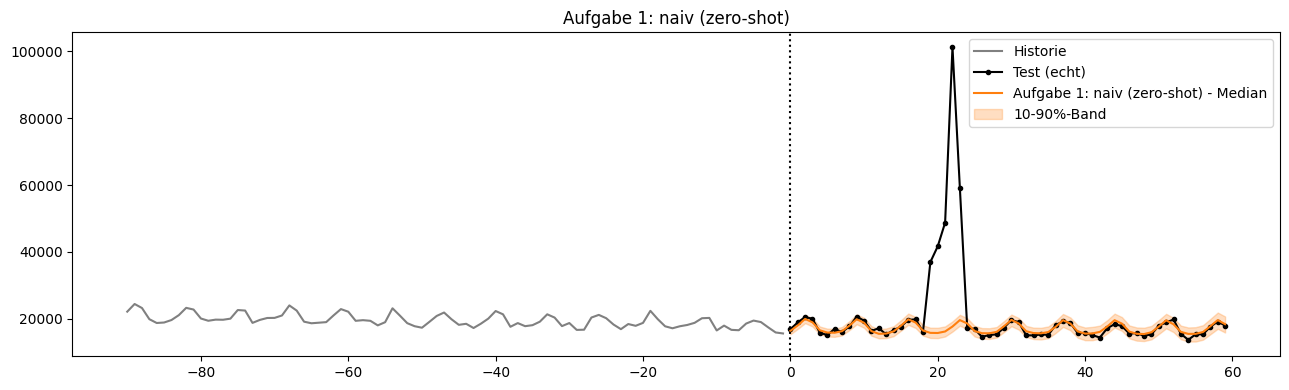

In [5]:
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# erstes Argument heißt 'inputs' (aktuelle Chronos-Version)
quantiles, mean = pipe.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
lo1     = quantiles[0, :, 0].numpy()
median1 = quantiles[0, :, 1].numpy()
hi1     = quantiles[0, :, 2].numpy()

m1 = print_metrics(y_test, median1, 'Aufgabe 1: naiv')
plot_forecast(y_train, y_test, median1, lo1, hi1, 'Aufgabe 1: naiv (zero-shot)')

**Kommentar:** Chronos ist zero-shot – die Punktprognose ist der Median (`quantiles[0,:,1]`), das Band kommt aus den Quantilen 0.1/0.9. Das naive Modell kennt den Kalender nicht und **verpasst den Black-Friday-Peak** im Test: Die **schwarze Spitze** Ende November (echte Testwerte) wird von der orangen Median-Linie glatt ignoriert – sie ragt sogar aus dem 10–90 %-Band heraus. *(Im Studenten-Notebook sind die Black-Friday-Tage im Übersichts-Plot unter 0.2 rot markiert.)*

---
## ✅ Lösung Aufgabe 2 – Black Friday als Kovariate (Chronos-2)

Das ist das **Experten-Modell**: Wir geben dem Modell die bekannte Information „an diesen Tagen ist Black Friday" mit – auch für die Zukunft (`future_df`).

In [6]:
from chronos import Chronos2Pipeline

pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

context_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][:-H].values,
    'target': y_train,
    'black_friday': df['black_friday'].to_numpy()[:-H],
})
future_df = pd.DataFrame({
    'id': 'skydrive',
    'timestamp': df['ds'][-H:].values,
    'black_friday': df['black_friday'].to_numpy()[-H:],
})

pred_df = pipe2.predict_df(
    context_df, future_df=future_df, prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)
lo2, median2, hi2 = (pred_df[q].to_numpy() for q in ['0.1', '0.5', '0.9'])
m2 = print_metrics(y_test, median2, 'Aufgabe 2: Chronos-2 + Black Friday')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Aufgabe 2: Chronos-2 + Black Friday RMSE=  4924.7  MAE=  1386.8  MAPE=  4.2%


---
## 📊 Showdown & Fazit

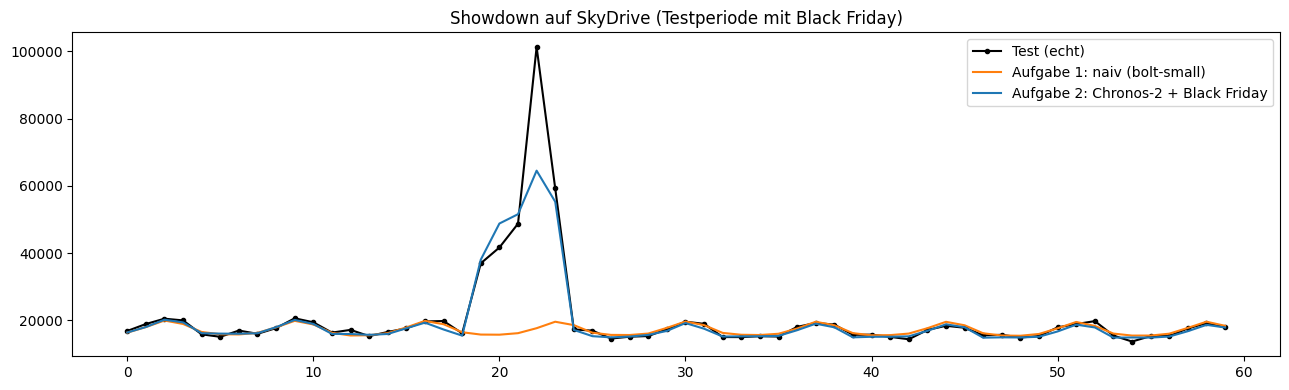

,RMSE,MAE,MAPE
label,,,
Aufgabe 1: naiv,13386.1,3955.1,9.1
Aufgabe 2: Chronos-2 + Black Friday,4924.7,1386.8,4.2


In [7]:
xf = np.arange(H)
plt.figure(figsize=(13, 4))
plt.plot(xf, y_test, color='black', marker='.', label='Test (echt)')
plt.plot(xf, median1, color='C1', label='Aufgabe 1: naiv (bolt-small)')
plt.plot(xf, median2, color='C0', label='Aufgabe 2: Chronos-2 + Black Friday')
plt.title('Showdown auf SkyDrive (Testperiode mit Black Friday)')
plt.legend(); plt.tight_layout(); plt.show()

pd.DataFrame([m1, m2]).set_index('label').round(1)

**Kommentar:** Chronos-2 + Kovariate trifft den Black Friday, den Bolt komplett verpasst (RMSE ≈ 13.400 → ≈ 4.900).

**Ehrlicher Hinweis für die Diskussion:** Der Löwenanteil kommt vom **Modellwechsel**, nicht vom Flag – Chronos-2 liegt auch *ohne* die Kovariate schon bei ≈ 5.000 (schnell nachzuprüfen: `future_df` und die `black_friday`-Spalten weglassen). Der Black Friday steckt nämlich **dreimal in der Historie**, und Chronos-2 erkennt solche Jahresmuster selbst. Die Kovariate wird entscheidend, wenn das Ereignis *nicht* aus der Historie ablesbar ist: unregelmäßige Termine (z. B. kurzfristige Promo-Aktionen), neue Events – oder **seltene Beispiele** wie bei Filiale `Hamburg` in Aufgabe 3, die erst einen einzigen Black Friday erlebt hat.

**Merksatz: Regelmäßiges lernt ein gutes Modell aus der Historie selbst – Unregelmäßiges oder nie Gesehenes muss man ihm sagen.**

---
## ✅ Lösung Aufgabe 3 – Drei Filialen, EIN Aufruf (Panel-Forecast)

Alle Serien in **eine** Tabelle stapeln, **ein** `predict_df`-Aufruf. `Hamburg` hat erst gut ein Jahr Historie – **ein einziger** Black Friday als Beispiel. Naiv (Bolt) reicht das nicht; mit der Kovariate versteht Chronos-2, was das Flag bedeutet.

In [8]:
# ============================================================
# AUFGABE-3-DATEN (vorgegeben) — 3 Filialen, gleiche Muster, andere Größe
# 'Hamburg' hat erst vor gut einem Jahr eröffnet -> genau EIN Black Friday in der Historie!
# ============================================================
from chronos import Chronos2Pipeline
if 'pipe2' not in globals():                     # falls Aufgabe 2 übersprungen wurde
    pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

rng3 = np.random.default_rng(seed=7)
base = (df['trend'] + df['weekly'] + df['yearly'] + df['bf_effect']).to_numpy()

factors = {'Berlin': 1.00, 'München': 1.35, 'Hamburg': 0.75}
start   = {'Berlin': 0,    'München': 0,    'Hamburg': len(base) - (400 + H)}  # ~13 Monate (enthält den BF 2022)

stores = {name: f * base + rng3.normal(0, 650, len(base)) for name, f in factors.items()}

# Pro Filiale: Kontext-Tabelle (Vergangenheit MIT Kovariate) + Future-Tabelle (bekannte Kovariaten-Zukunft)
ctx_list, fut_list = [], []
for name in factors:
    s0 = start[name]
    ctx_list.append(pd.DataFrame({'id': name,
                                  'timestamp': df['ds'].iloc[s0:-H].values,
                                  'target': stores[name][s0:-H],
                                  'black_friday': df['black_friday'].to_numpy()[s0:-H]}))
    fut_list.append(pd.DataFrame({'id': name,
                                  'timestamp': df['ds'].iloc[-H:].values,
                                  'black_friday': df['black_friday'].to_numpy()[-H:]}))

for name in factors:
    print(f"{name:<10} Historie: {len(stores[name][start[name]:-H]):4d} Tage | Test: {H} Tage")

Berlin     Historie: 1401 Tage | Test: 60 Tage
München    Historie: 1401 Tage | Test: 60 Tage
Hamburg    Historie:  400 Tage | Test: 60 Tage


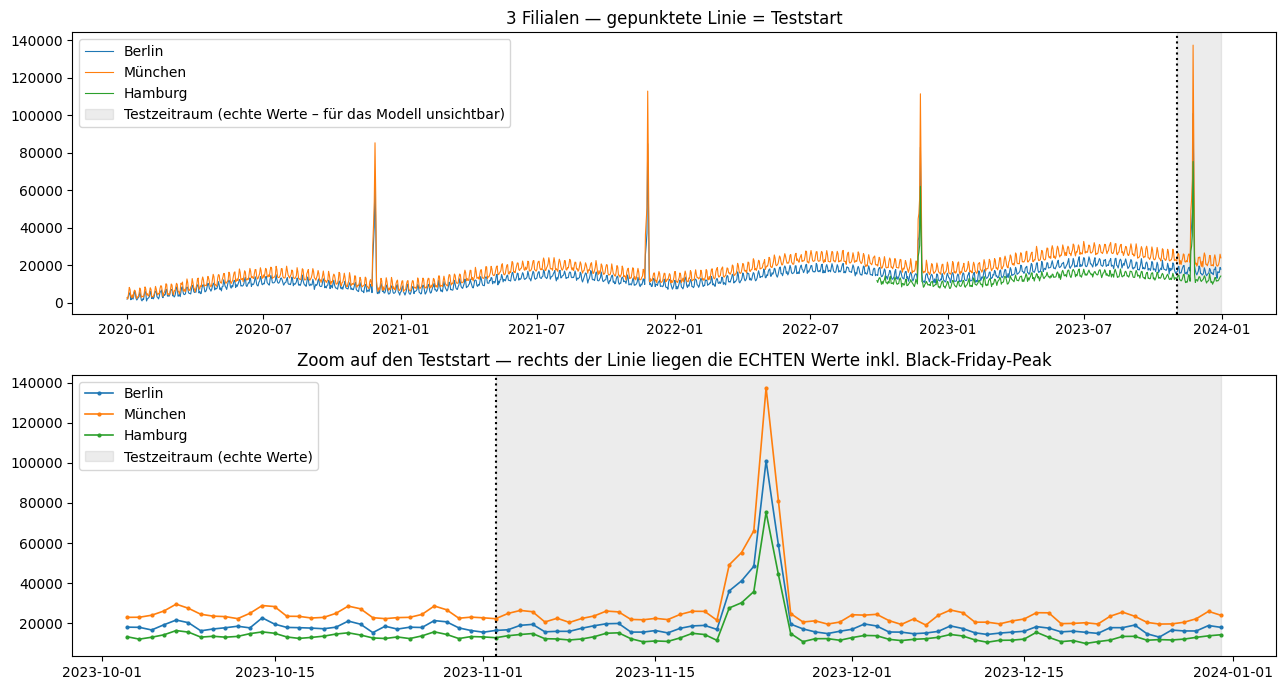

In [9]:
# Die drei Filialen ansehen (vorgegeben) — oben gesamt, unten Zoom auf den Teststart.
# Grau schattiert = Testzeitraum: Diese ECHTEN Werte (inkl. Black-Friday-Peak) sieht
# das Modell nicht — genau sie gilt es vorherzusagen.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

for name in factors:
    s0 = start[name]
    ax1.plot(df['ds'].iloc[s0:], stores[name][s0:], lw=0.8, label=name)
ax1.axvspan(df['ds'].iloc[-H], df['ds'].iloc[-1], color='gray', alpha=0.15,
            label='Testzeitraum (echte Werte – für das Modell unsichtbar)')
ax1.axvline(df['ds'].iloc[-H], color='k', ls=':')
ax1.set_title('3 Filialen — gepunktete Linie = Teststart')
ax1.legend()

zoom0 = len(df) - H - 30
for name in factors:
    ax2.plot(df['ds'].iloc[zoom0:], stores[name][zoom0:], lw=1.2, marker='.', ms=4, label=name)
ax2.axvspan(df['ds'].iloc[-H], df['ds'].iloc[-1], color='gray', alpha=0.15,
            label='Testzeitraum (echte Werte)')
ax2.axvline(df['ds'].iloc[-H], color='k', ls=':')
ax2.set_title('Zoom auf den Teststart — rechts der Linie liegen die ECHTEN Werte inkl. Black-Friday-Peak')
ax2.legend()
plt.tight_layout(); plt.show()

In [10]:
# --- Lösung: Panel bauen + EIN Aufruf für alle Filialen ---
context_mv = pd.concat(ctx_list, ignore_index=True)   # 3 Filial-Tabellen untereinander -> EINE Tabelle
future_mv  = pd.concat(fut_list, ignore_index=True)   # dito: bekannte Kovariaten-Zukunft aller Filialen

pred_mv = pipe2.predict_df(
    context_mv, future_df=future_mv, prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)

# So sieht die Antwort von Chronos-2 aus: EINE Zeile pro Filiale UND Zukunftstag.
#   id          -> welche Filiale (3 Filialen x 60 Tage = 180 Zeilen)
#   timestamp   -> welcher Testtag (2023-11-02 bis 2023-12-31, nahtlos an die Historie anschließend)
#   0.1/0.5/0.9 -> Quantile; '0.5' (Median) ist die Punktprognose
# head() zeigt nur die ersten 5 Zeilen -> deshalb hier nur Berlin, Anfang November.
print(pred_mv.head())

       id  timestamp target_name   predictions           0.1           0.5  \
0  Berlin 2023-11-02      target  16353.446289  15618.167969  16353.446289   
1  Berlin 2023-11-03      target  18143.078125  17317.621094  18143.078125   
2  Berlin 2023-11-04      target  20046.048828  19187.277344  20046.048828   
3  Berlin 2023-11-05      target  19552.550781  18719.078125  19552.550781   
4  Berlin 2023-11-06      target  15971.859375  15201.799805  15971.859375   

            0.9  
0  17192.843750  
1  19046.441406  
2  20990.753906  
3  20542.519531  
4  16793.210938  


## 📊 Auswertung Aufgabe 3 *(vorgegeben – einfach ausführen)*

Diese Zelle beantwortet **eine** Frage: *Wie viel besser ist die Panel-Prognose als ein naiver Einzelkämpfer?* Dafür braucht sie drei Zutaten:

1. **Der Gegner:** Bolt-small aus Aufgabe 1. Er bekommt jede Filiale **einzeln** und ohne Kovariate – drei getrennte Aufrufe, während das Panel nur EINEN brauchte.
2. **Der Schiedsrichter:** Für jede Filiale werden beide Prognosen an den echten 60 Testtagen gemessen (RMSE, kleiner = besser) → Tabelle und Balkendiagramm.
3. **Die Vorhersagen im Vergleich:** Zum Schluss pro Filiale ein Bild – echte Testwerte (schwarz) gegen beide Prognosen (orange = Bolt einzeln, blau = Panel). Achte besonders auf **Hamburg**: Bolt hat in seiner kurzen Historie zwar EINEN Black Friday gesehen, kann ihn aber nicht deuten und zieht eine flache Linie. Chronos-2 kombiniert dieses **eine Beispiel** mit der **Kovariate** (die sagt: »jetzt wieder!«) – und trifft den Peak.

> **Fairness-Hinweis:** Der Vergleich ist bewusst *unfair* („naiv & einzeln" gegen „alles"), um den Gesamteffekt der Zusatzinfos zu zeigen – siehe Diskussionsfrage 3.

RMSE je Filiale (kleiner = besser)
            Bolt-small (einzeln, naiv)  Chronos-2 (Panel + Kovariate)
Filiale                                                              
Berlin                         13265.5                         4717.0
München                        17995.4                         6618.5
Hamburg                         9753.9                         4206.6
Ø (Mittel)                     13671.6                         5180.7


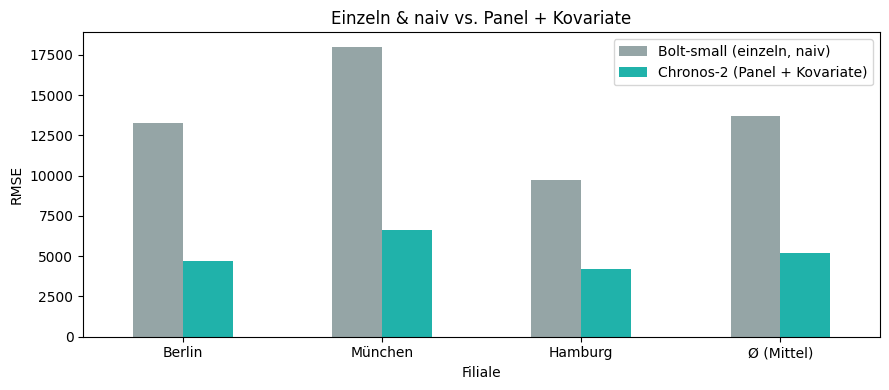

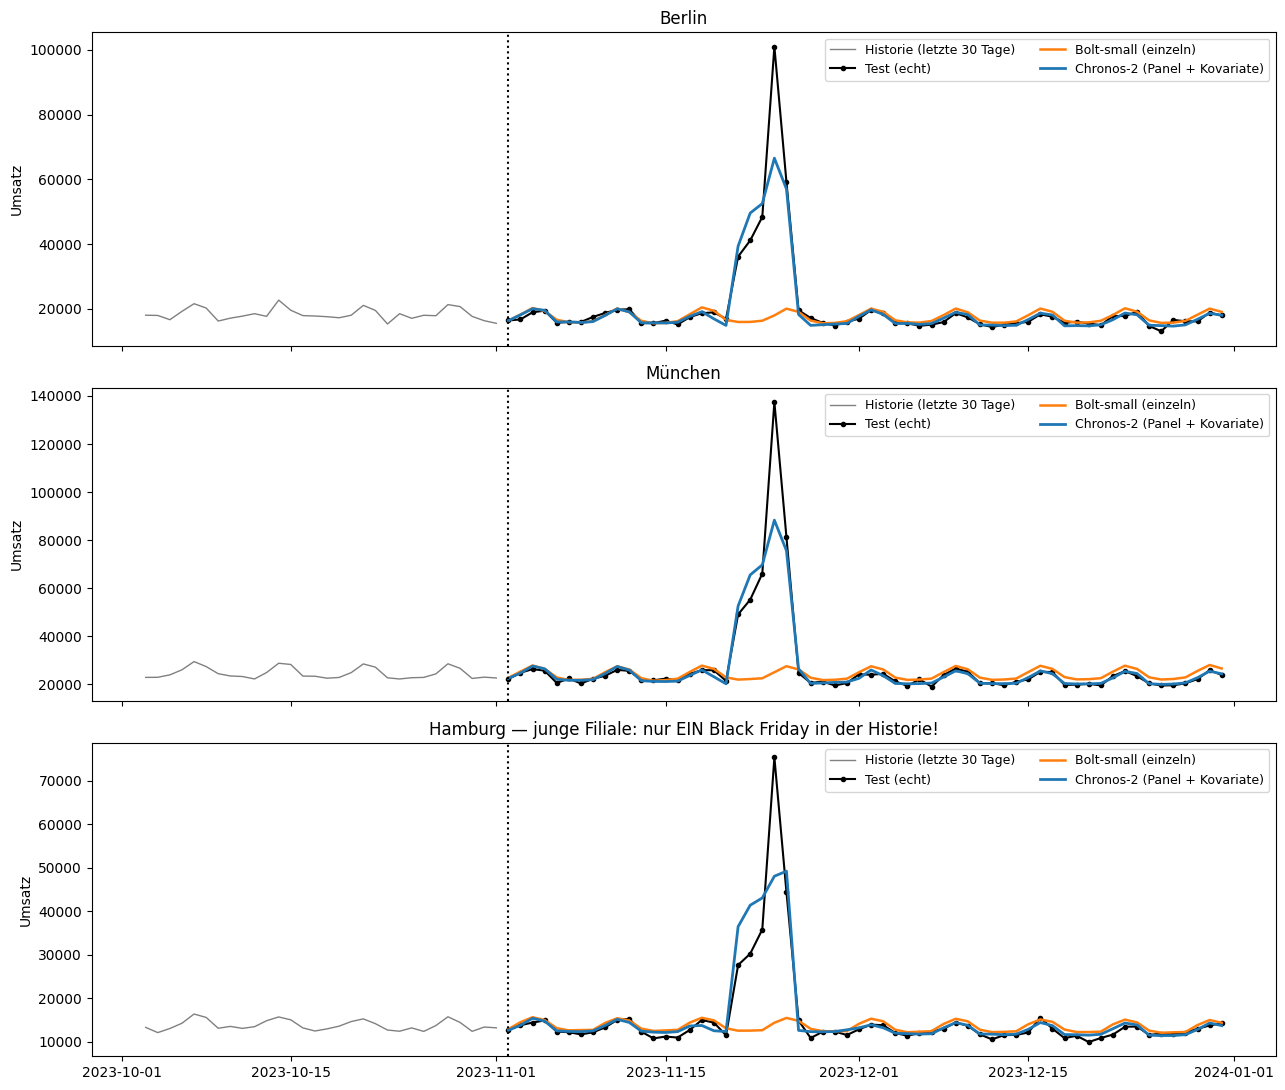

In [11]:
# ============================================================
# AUSWERTUNG (vorgegeben) — Wie viel besser ist das Panel als ein Einzelkämpfer?
# Ablauf: 1) Gegner laden  2) pro Filiale beide Prognosen holen
#         3) RMSE-Tabelle  4) Balkendiagramm  5) Blick auf Hamburg
# ============================================================

# --- 1) Der GEGNER: Bolt-small aus Aufgabe 1 --------------------------------
#     Er bekommt weder Kovariate noch Panel: jede Filiale einzeln, nur Historie.
if 'pipe' not in globals():                      # nur laden, falls noch nicht da
    pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

rows, bolt_med = [], {}
for name in factors:                             # 'Berlin', 'München', 'Hamburg'
    # --- 2a) Daten DIESER Filiale herausschneiden ---------------------------
    y_tr = stores[name][start[name]:-H]          # Historie (Hamburg: nur ~13 Monate!)
    y_te = stores[name][-H:]                     # echte letzte 60 Tage = "Prüfungsbogen"

    # --- 2b) Prognose des Gegners: EIN Aufruf PRO Filiale, isoliert ----------
    q, _ = pipe.predict_quantiles(inputs=torch.tensor(y_tr, dtype=torch.float32),
                                  prediction_length=H, quantile_levels=[0.1, 0.5, 0.9])
    bolt_med[name] = q[0, :, 1].numpy()          # Median merken (für den Hamburg-Plot)

    # --- 2c) DEINE Panel-Prognose aus der großen Tabelle filtern -------------
    #     pred_mv hat eine Zeile pro Filiale UND Tag -> die id-Spalte trennt sie.
    med_c2 = pred_mv.loc[pred_mv['id'] == name, '0.5'].to_numpy()   # 60 Median-Werte

    # --- 2d) Der SCHIEDSRICHTER: beide gegen die echten Werte messen ---------
    rows.append({'Filiale': name,
                 'Bolt-small (einzeln, naiv)': np.sqrt(mean_squared_error(y_te, bolt_med[name])),
                 'Chronos-2 (Panel + Kovariate)': np.sqrt(mean_squared_error(y_te, med_c2))})

# --- 3) Ergebnis-Tabelle: eine Zeile pro Filiale + Durchschnitt --------------
mv = pd.DataFrame(rows).set_index('Filiale')
mv.loc['Ø (Mittel)'] = mv.mean()
print('RMSE je Filiale (kleiner = besser)')
print(mv.round(1))

# --- 4) Dieselbe Tabelle als Bild: pro Filiale zwei Balken -------------------
#     grau = Gegner (einzeln & naiv), türkis = dein Panel + Kovariate
ax = mv.plot.bar(figsize=(9, 4), color=['#95A5A6', '#20B2AA'], rot=0)
ax.set_ylabel('RMSE'); ax.set_title('Einzeln & naiv vs. Panel + Kovariate')
plt.tight_layout(); plt.show()

# --- 5) Die Vorhersagen im Vergleich: pro Filiale echt vs. beide Prognosen ---
#     grau = letzte 30 Tage Historie | schwarz = echte Testwerte
#     orange = Bolt (einzeln, naiv)  | blau = Chronos-2 (Panel + Kovariate)
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
for ax, name in zip(axes, factors):
    ax.plot(df['ds'].iloc[-H-30:-H], stores[name][-H-30:-H], color='gray', lw=1,
            label='Historie (letzte 30 Tage)')
    test_x = df['ds'].iloc[-H:]
    ax.plot(test_x, stores[name][-H:], color='black', marker='.', label='Test (echt)')
    ax.plot(test_x, bolt_med[name], color='C1', lw=1.8, label='Bolt-small (einzeln)')
    ax.plot(test_x, pred_mv.loc[pred_mv['id'] == name, '0.5'].to_numpy(), color='C0', lw=2,
            label='Chronos-2 (Panel + Kovariate)')
    ax.axvline(df['ds'].iloc[-H], color='k', ls=':')
    extra = ' — junge Filiale: nur EIN Black Friday in der Historie!' if name == 'Hamburg' else ''
    ax.set_title(f'{name}{extra}')
    ax.set_ylabel('Umsatz'); ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

**Kommentar:** In `Berlin` und `München` wirkt die Kovariate voll: Die Flags korrelieren in der Historie klar mit den Spitzen, Chronos-2 überträgt das auf die Zukunfts-Flags. `Hamburg` ist der Härtetest: Bolt sieht seinen einen Black Friday, kann ihn aber nicht deuten. Chronos-2 braucht genau dieses **eine Beispiel** – Flag plus Spitze in der eigenen Historie –, um den kommenden Peak zu treffen.

**Wichtige, ehrliche Erkenntnis:** Kovariaten-Beziehungen lernt Chronos-2 **pro Serie im Kontext**. Mit 90 Tagen Historie (null Black Fridays, Flag überall 0) verpasst auch der Panel-Forecast den Peak – die Beziehung wandert *nicht* automatisch von den anderen Filialen herüber. Das Panel spart Aufwand (ein Aufruf, eine Tabelle), ersetzt aber keine fehlenden Beispiele.

> **Fairness-Hinweis (Diskussionsfrage 3):** „Bolt einzeln + naiv" vs. „Chronos-2 + alles" ist bewusst *unfair* – es zeigt, was die Zusatzinfos ausmachen. Ein fairer Vergleich hielte den Wissensstand konstant, z. B. Chronos-2 einzeln & univariat vs. Chronos-2 Panel + Kovariate.

---
## 💬 Antworten zu den Diskussionsfragen

**1. Warum funktioniert Chronos ohne `fit()` und ohne Feiertage?**
Chronos ist auf sehr vielen Zeitreihen **vortrainiert** und hat typische Muster (Trend, Wochen-/Jahressaison) bereits gelernt. Es überträgt dieses Wissen *zero-shot* auf neue Reihen – ähnlich wie ein Sprachmodell Texte vervollständigt, ohne für jeden Text neu trainiert zu werden.

**2. Warum reicht `Hamburg` EIN Black Friday – und null hätten nicht gereicht?**
Chronos-2 lernt die Bedeutung einer Kovariate **im Kontext jeder einzelnen Serie**: Es sieht »Flag = 1 → Umsatzspitze« in der eigenen Historie und wendet das auf die Zukunfts-Flags an. Ein Beispiel genügt dafür. Mit 90 Tagen Historie (Flag überall 0) gäbe es **kein einziges Beispiel** – und die Beziehung überträgt sich auch nicht automatisch von Berlin/München herüber. Zum Ausprobieren: `start['Hamburg']` auf `len(base) - (90 + H)` setzen – der Peak verschwindet.

**3. Was wäre ein fairer Vergleich?**
Gleicher Wissensstand auf beiden Seiten: z. B. Chronos-2 *einzeln & univariat* vs. Chronos-2 *Panel + Kovariate* (isoliert die Zusatzinfos), oder Bolt vs. Chronos-2 *beide univariat* (isoliert die Architektur). Der Vergleich in Aufgabe 3 ist absichtlich unfair – er zeigt den Gesamteffekt der Zusatzinfos.

**4. Prophet oder Chronos?**
- **Prophet:** wenn Erklärbarkeit zählt, Domänenwissen (Feiertage, Aktionen) klar einbaubar ist, wenig Rechenleistung da ist.
- **Chronos:** wenn schnell ein starker Forecast ohne Feature-Engineering gebraucht wird, **viele Reihen parallel** zu prognostizieren sind (Aufgabe 3!), und ein Black-Box-Modell akzeptabel ist.